In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
sys.path.append('./tools')

import plot_from_log as pfl

In [4]:
'''
Comments for each of the files:

0, data_20260519_203733: inlet_choked,yes
1, data_20260519_204401: inlet_choked,yes
2, data_20260519_204443: inlet_choked,yes - showing that 13% speed at compressor is not enough to overcome chamber pressure backflow
3, data_20260519_205158: inlet_choked,no - checking at which minimum duty cycle the compressor can maintain adequate pressure
4, data_20260519_210630: inlet_choked,yes - showing that we can't pressurize the chamber with a choked inlet even if the piston is full power
5, data_20260519_213040: inlet_choked,no
6, data_20260606_194117: inlet_choked,only_compressor_manual_outlet
7, data_20260606_200711: inlet_choked,flow_rate_dpump_pressurising
8, data_20260606_201104: inlet_choked,ppump_only_choked_outlet
9, data_20260606_202038: inlet_choked,dpump_only_choked_inlet_the_betterOne
10, data_20260606_202452: inlet_choked,dpump_only_choked_inlet_the_betterOne
11, data_20260606_204601: inlet_choked,full_system_choked_inlet_TheBetterOne_manualOutlet
12, data_20260606_205954: inlet_choked,dpump_only_choked_inlet_TheBetterOne_chokedOutlet
13, data_20260606_210134: inlet_choked,dpump_only_choked_inlet_TheWorseOne_chokedOutlet
14, data_20260628_150733: Leakage test
'''


paths = [
    r'.\logs\data_20260519_203733.csv',
    r'.\logs\data_20260519_204401.csv',
    r'.\logs\data_20260519_204443.csv',
    r'.\logs\data_20260519_205158.csv',
    r'.\logs\data_20260519_210630.csv',
    r'.\logs\data_20260519_213040.csv',
    r'.\logs\data_20260606_194117.csv',
    r'.\logs\data_20260606_200711.csv',
    r'.\logs\data_20260606_201104.csv',
    r'.\logs\data_20260606_202038.csv',
    r'.\logs\data_20260606_202452.csv',
    r'.\logs\data_20260606_204601.csv',
    r'.\logs\data_20260606_205954.csv',
    r'.\logs\data_20260606_210134.csv',
    r'.\logs\data_20260628_150733.csv'
]

p1 = paths[11]
p2 = paths[12]
p3 = paths[14] #4

In [5]:
df1 = pd.read_csv(p1, skiprows=1, usecols=[1,2,3,4,5,6])
df2 = pd.read_csv(p2, skiprows=1, usecols=[1,2,3,4,5,6])
df3 = pd.read_csv(p3, skiprows=1, usecols=[1,2,3,4,5,6])
df2.head(30)

,ts_ms,diaphragm_pct,piston_pct,mpx_pressure_hPa,bmp_temp_C,bmp_pressure_hPa
0,1130,0,0,-15.86,22.93,1011.35
1,2023,0,0,-15.86,22.93,1011.32
2,3022,0,0,-15.86,22.93,1011.28
3,4023,0,0,-15.86,22.93,1011.21
4,5022,0,0,-15.86,22.93,1011.20
5,6023,0,0,-15.86,22.93,1011.17
6,7022,0,0,-15.86,22.93,1011.10
7,8023,0,0,-15.86,22.93,1011.10
8,9023,0,0,-15.86,22.93,1011.08
9,10022,0,0,-15.86,22.93,1011.08


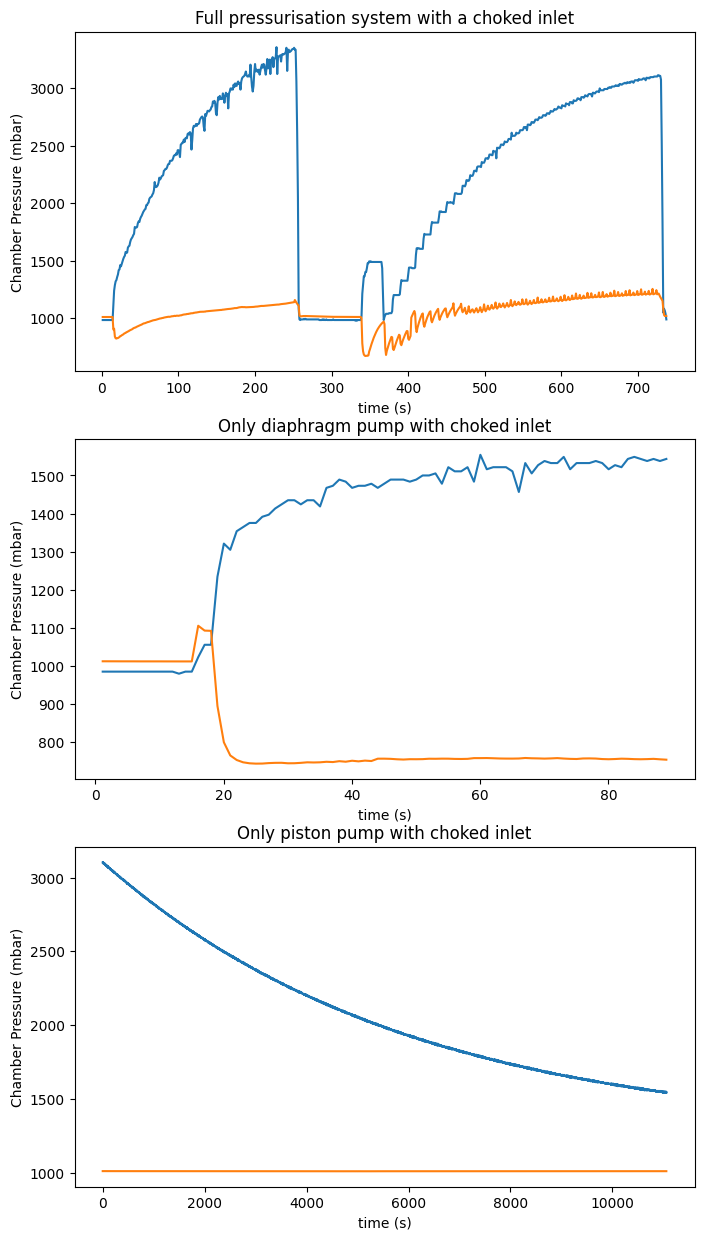

In [6]:
fig,axes = plt.subplots(3,1, figsize=(8,15))

axes[0].set_title('Full pressurisation system with a choked inlet')
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('Chamber Pressure (mbar)')
axes[0].plot(df1.ts_ms/1000, df1.mpx_pressure_hPa+1000)
axes[0].plot(df1.ts_ms/1000, df1.bmp_pressure_hPa)

axes[1].set_title('Only diaphragm pump with choked inlet')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('Chamber Pressure (mbar)')
axes[1].plot(df2.ts_ms/1000, df2.mpx_pressure_hPa+1000)
axes[1].plot(df2.ts_ms/1000, df2.bmp_pressure_hPa)

axes[2].set_title('Only piston pump with choked inlet')
axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('Chamber Pressure (mbar)')
axes[2].plot(df3.ts_ms/1000, df3.mpx_pressure_hPa+1000)
axes[2].plot(df3.ts_ms/1000, df3.bmp_pressure_hPa)

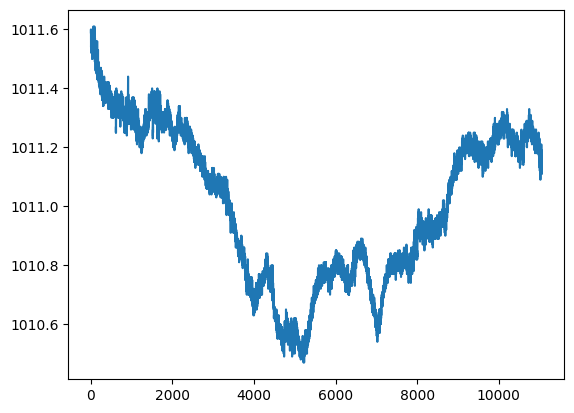

In [7]:
plt.plot(df3.ts_ms/1000, df3.bmp_pressure_hPa)

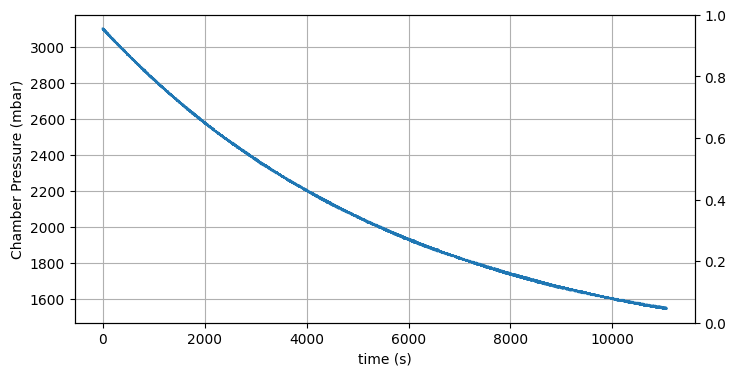

In [12]:
fig, axes = plt.subplots(1,1,figsize=(8,4))
p1 = axes.plot(df3.ts_ms/1000, df3.mpx_pressure_hPa+1000)
axes.set_ylabel('Chamber Pressure (mbar)')
axes.set_xlabel('time (s)')
ax2 = axes.twinx()
axes.grid(True)

#p2 = ax2.plot(df3.ts_ms/1000,df3.piston_pct, color='orange', linestyle='dashed')
#ax2.set_ylabel('Duty cycle (%)')

In [9]:
df3.loc[np.abs(df3.mpx_pressure_hPa-2000)<20]

,ts_ms,diaphragm_pct,piston_pct,mpx_pressure_hPa,bmp_temp_C,bmp_pressure_hPa
281,282022,0,0,2015.21,23.38,1011.40
284,285023,0,0,2015.21,23.39,1011.40
285,286022,0,0,2015.21,23.38,1011.40
286,287023,0,0,2015.21,23.38,1011.37
287,288022,0,0,2015.21,23.39,1011.38
...,...,...,...,...,...,...
412,413023,0,0,1982.62,23.36,1011.38
415,416022,0,0,1982.62,23.37,1011.39
416,417022,0,0,1982.62,23.36,1011.40
418,419022,0,0,1982.62,23.36,1011.35


In [10]:
df3.iloc[391]

ts_ms               392023.00
diaphragm_pct            0.00
piston_pct               0.00
mpx_pressure_hPa      1988.05
bmp_temp_C              23.37
bmp_pressure_hPa      1011.38
Name: 391, dtype: float64